# 01 Explore

First look at the transactions in `data/fraud.duckdb` (built by `python -m src.load`).

The monthly chart uses all 24 months so we can see where the split falls. The category, hour and amount charts use only **train + validation** months (before the test start in `config.yaml`), so the test months stay unseen while we decide which features to build.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import yaml

# The notebook runs from notebooks/, so the project root is one level up.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
config = yaml.safe_load((ROOT / "config.yaml").read_text())
TEST_START = config["split"]["validation_end"]

# read_only: the notebook can never change the data.
con = duckdb.connect(str(ROOT / "data" / "fraud.duckdb"), read_only=True)

def query(sql):
    """Run SQL and return a pandas DataFrame."""
    return con.sql(sql).df()

# Only rows before the test period, used for the pattern charts.
BEFORE_TEST = f"WHERE trans_date_trans_time < TIMESTAMP '{TEST_START}'"

## 1. Fraud rate overall and by month

1,852,394 transactions, 9,651 fraud, rate 0.521%
from 2019-01-01 00:00:18 to 2020-12-31 23:59:34


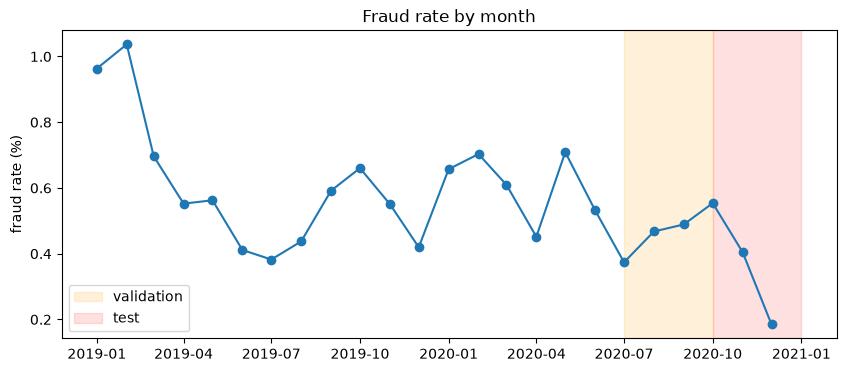

In [2]:
overall = query("SELECT COUNT(*) AS n, SUM(is_fraud)::BIGINT AS fraud, AVG(is_fraud) AS rate,"
                "MIN(trans_date_trans_time) AS earliest, MAX(trans_date_trans_time) AS latest FROM transactions")
print(f"{overall.n[0]:,} transactions, {overall.fraud[0]:,} fraud, rate {overall.rate[0]:.3%}")
print(f"from {overall.earliest[0]} to {overall.latest[0]}")

monthly = query("""
    SELECT date_trunc('month', trans_date_trans_time) AS month,
           COUNT(*) AS n, AVG(is_fraud) AS rate
    FROM transactions GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.month, monthly.rate * 100, marker="o")
# shade the validation and test months
ax.axvspan(np.datetime64(config["split"]["train_end"]), np.datetime64(TEST_START), color="orange", alpha=0.15, label="validation")
ax.axvspan(np.datetime64(TEST_START), np.datetime64("2021-01-01"), color="red", alpha=0.12, label="test")
ax.legend()
ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate by month")
plt.show()

**Takeaway:** about 0.52% of transactions are fraud overall, but the monthly rate swings between about 0.2% and 1.0%. In both Decembers transaction volume roughly doubles while fraud does not, and December 2020 is the lowest month of all (0.19%), so the test months (Oct–Dec 2020) have a lower fraud rate than training.

## 2. Fraud rate by category (before test period)

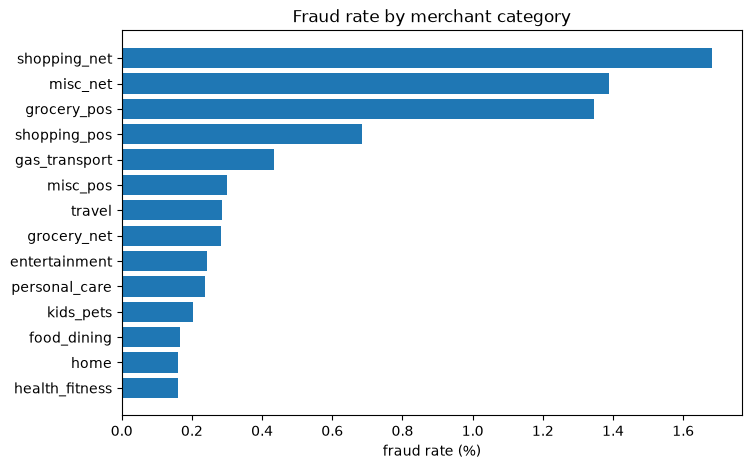

In [3]:
by_category = query(f"""
    SELECT category, COUNT(*) AS n, AVG(is_fraud) AS rate
    FROM transactions {BEFORE_TEST} GROUP BY 1 ORDER BY rate
""")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_category.category, by_category.rate * 100)
ax.set_xlabel("fraud rate (%)")
ax.set_title("Fraud rate by merchant category")
plt.show()

**Takeaway:** online shopping (`shopping_net`), online miscellaneous (`misc_net`) and in-store groceries (`grocery_pos`) have fraud rates of 1.3–1.7%, roughly ten times the 0.16–0.3% of categories like home, health and dining.

## 3. Fraud rate by hour of day (before test period)

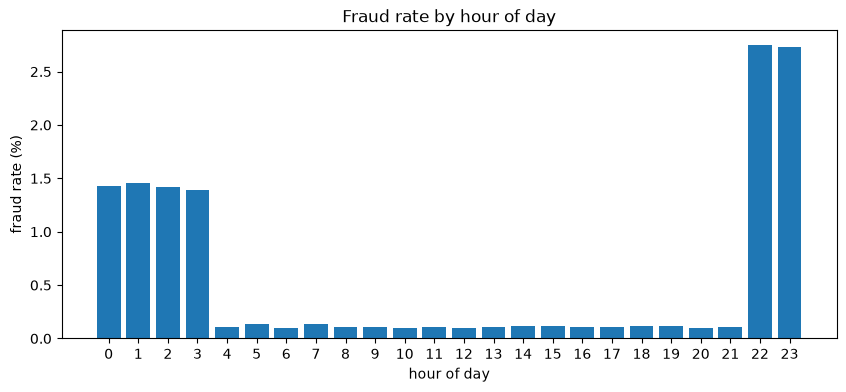

In [4]:
by_hour = query(f"""
    SELECT hour(trans_date_trans_time) AS hour, AVG(is_fraud) AS rate
    FROM transactions {BEFORE_TEST} GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.hour, by_hour.rate * 100)
ax.set_xticks(range(24))
ax.set_xlabel("hour of day")
ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
plt.show()

**Takeaway:** fraud is concentrated between 22:00 and 03:59, where the rate is about 1.4–2.8%, against about 0.1% for every hour from 04:00 to 21:59.

## 4. Amounts, fraud vs legitimate (before test period, log scale)

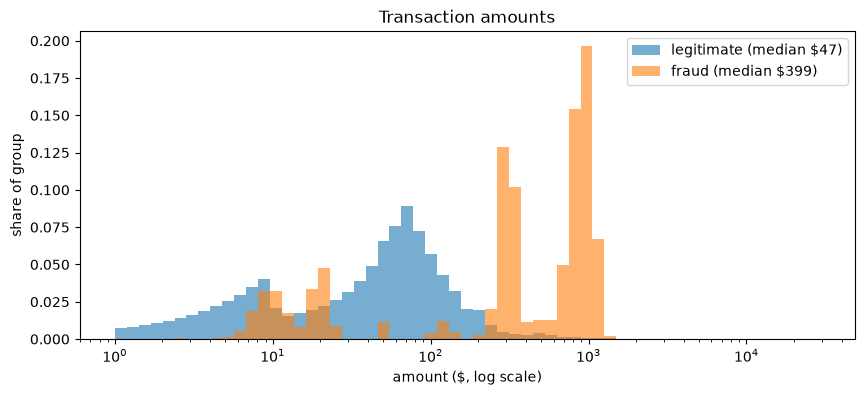

,band,n,fraud,rate_pct
0,1: under $100,1286501,1914,0.15
1,2: $100-499,265645,2563,0.96
2,3: $500+,18727,4238,22.63


In [5]:
amounts = query(f"SELECT amt, is_fraud FROM transactions {BEFORE_TEST}")

bins = np.logspace(0, np.log10(amounts.amt.max()), 60)
fig, ax = plt.subplots(figsize=(10, 4))
for label, value in [("legitimate", 0), ("fraud", 1)]:
    group = amounts.amt[amounts.is_fraud == value]
    # weights make each group sum to 1, so the small fraud group is visible next to the large legitimate one
    ax.hist(group, bins=bins, weights=np.ones(len(group)) / len(group), alpha=0.6, label=f"{label} (median ${group.median():.0f})")
ax.set_xscale("log")
ax.set_xlabel("amount ($, log scale)")
ax.set_ylabel("share of group")
ax.set_title("Transaction amounts")
ax.legend()
plt.show()

query(f"""
    SELECT CASE WHEN amt < 100 THEN '1: under $100' WHEN amt < 500 THEN '2: $100-499' ELSE '3: $500+' END AS band,
           COUNT(*) AS n, SUM(is_fraud)::BIGINT AS fraud, ROUND(100 * AVG(is_fraud), 2) AS rate_pct
    FROM transactions {BEFORE_TEST} GROUP BY 1 ORDER BY 1
""")

**Takeaway:** fraud amounts are much larger (median about \$400 against about \$47 for legitimate), fraud clusters around \$300 and \$800–1,000 and never goes above about \$1,400, and transactions of \$500 or more are fraud about 23% of the time, against 0.15% under \$100.

In [6]:
con.close()